# Time-Series Exploration

This notebook is Phase 3, Section 5 of the Delhi AQI / GRAP project: **Time-Series
Exploration**.

**Scope of this notebook.** We describe how pollution and weather readings evolve
over time -- month by month across the full study period, and month by month
compared between the two calendar years. This is descriptive EDA only.

**Deliberately out of scope here.** No GRAP stage analysis, no comparison between
policy stages, no causal reasoning about why any trend looks the way it does, no
forecasting, and no model fitting. Those all require assumptions this notebook does
not make.

> The notebook assumes it is run from the `notebooks/` folder, so the data path
> below starts with `../`. This notebook does not modify any earlier notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to the merged analytical dataset built in Phase 2.
# This assumes the notebook is run from the 'notebooks/' folder.
data_path = '../data/processed/station_daily_grap.csv'

# Load the dataset and convert the date column to real dates so it can be
# grouped by calendar month.
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])

# year_month is a single chronological label (e.g. 2022-01) that keeps the two
# years in their correct time order, for the whole-period charts below.
df['year_month'] = df['date'].dt.to_period('M')

# month_number (1-12) ignores the year, for the calendar-month comparisons and
# variability views later in the notebook.
df['month_number'] = df['date'].dt.month

df.head()

,station_id,station_name,date,year,pm25_ugm3,pm10_ugm3,air_temp_c,rh_pct,wind_speed_ms,wind_dir_deg,season,grap_stage,is_event_day,days_since_last_change,days_until_next_change,source_file,year_month,month_number
0,anand_vihar,Anand Vihar,2022-01-01,2022,393.56,598.82,13.97,75.32,0.32,230.10,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv",2022-01,1
1,anand_vihar,Anand Vihar,2022-01-02,2022,424.81,598.95,14.33,75.32,0.32,230.36,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv",2022-01,1
2,anand_vihar,Anand Vihar,2022-01-03,2022,375.52,636.12,14.79,72.44,0.35,223.51,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv",2022-01,1
3,anand_vihar,Anand Vihar,2022-01-04,2022,291.86,564.58,16.14,66.95,0.31,209.49,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv",2022-01,1
4,anand_vihar,Anand Vihar,2022-01-05,2022,353.05,449.37,14.45,86.60,0.89,138.08,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv",2022-01,1


**What this does.** Loads the merged Phase 2 dataset and converts `date` into a
real datetime column. It then derives two time labels used throughout this
notebook: `year_month`, a chronological year-and-month label that keeps 2022 and
2023 in order, and `month_number`, the calendar month (1-12) on its own.

**Why analysts use this analysis.** Almost every chart in this notebook is a
monthly aggregate, so both time labels are built once, up front, rather than
recomputed inside every section.

**How to interpret the output.** Confirm the preview shows a valid `date`, and
that `year_month` and `month_number` look correct (for example, a January 2022
row should show `year_month` = 2022-01 and `month_number` = 1).

# Section 1 -- Monthly Observation Counts

Before looking at any trend, we confirm that every month in the dataset has the
number of station-day rows we would expect, given eight stations and that
month's length.

In [2]:
# Count how many rows (station-days) fall in each chronological month.
monthly_counts = df.groupby('year_month').size().reset_index(name='Observed Count')

# The expected count for a month is the number of stations multiplied by the
# number of calendar days in that month.
number_of_stations = df['station_name'].nunique()
monthly_counts['Days in Month'] = monthly_counts['year_month'].dt.days_in_month
monthly_counts['Expected Count'] = number_of_stations * monthly_counts['Days in Month']

# Flag whether each month's observed count matches what was expected.
monthly_counts['Matches Expected'] = (
    monthly_counts['Observed Count'] == monthly_counts['Expected Count']
)

monthly_counts.columns = [
    'Month', 'Observed Count', 'Days in Month', 'Expected Count', 'Matches Expected'
]
monthly_counts

,Month,Observed Count,Days in Month,Expected Count,Matches Expected
0,2022-01,248,31,248,True
1,2022-02,224,28,224,True
2,2022-03,248,31,248,True
3,2022-04,240,30,240,True
4,2022-05,248,31,248,True
5,2022-06,240,30,240,True
6,2022-07,248,31,248,True
7,2022-08,248,31,248,True
8,2022-09,240,30,240,True
9,2022-10,248,31,248,True


**What this does.** Groups the dataset by chronological month and counts the
rows in each group. It separately computes how many rows *should* exist in each
month (stations x days in that month) and compares the two counts.

**Why analysts use this analysis.** A monthly trend line is only trustworthy if
every month contributes a similar, complete amount of data. Checking coverage
first prevents a later chart from silently understating or overstating a month
simply because that month has fewer underlying observations.

**How to interpret the output.** `Matches Expected` should read `True` for every
row. A `False` row means that month has more or fewer station-day rows than a
full calendar would predict, which is worth keeping in mind (though not
diagnosing) before reading the monthly charts that follow.

# Section 2 -- Monthly Mean Pollution

We now look at how mean PM2.5 and mean PM10 move across the full, chronological
study period, one line chart per pollutant.

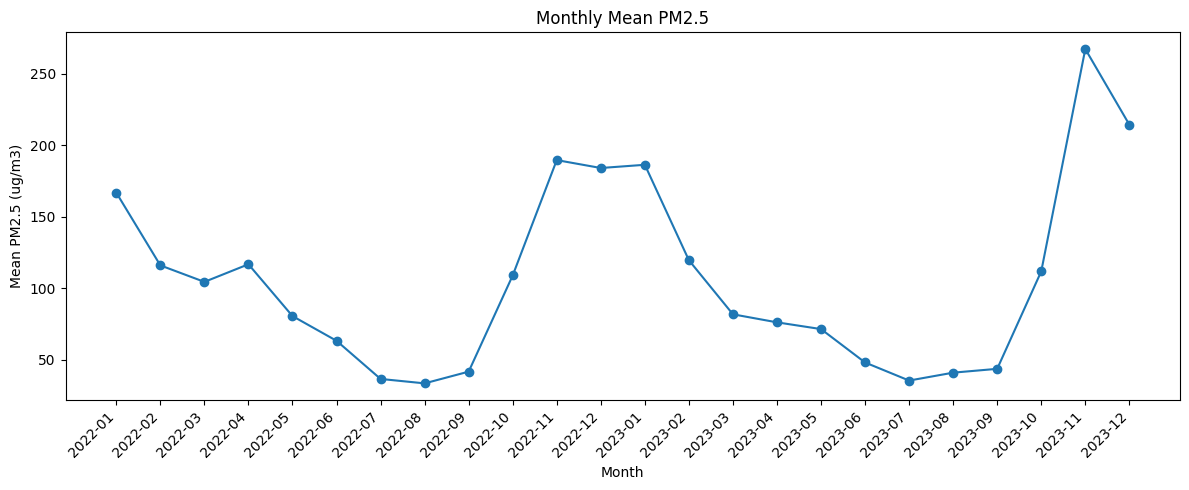

In [3]:
# Mean PM2.5 for each chronological month, in time order.
monthly_mean_pm25 = df.groupby('year_month')['pm25_ugm3'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_mean_pm25.index.astype(str), monthly_mean_pm25.values, marker='o')
plt.title('Monthly Mean PM2.5')
plt.xlabel('Month')
plt.ylabel('Mean PM2.5 (ug/m3)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What this does.** Groups the dataset by chronological month, averages PM2.5
within each month, and plots those monthly averages as a single line in time
order from the first month in the dataset to the last.

**Why analysts use this analysis.** A monthly average smooths out day-to-day
noise, making slower, month-scale movement in pollution visible in a way that a
raw daily series cannot. A line chart is the standard way to show a single
variable's evolution across an ordered time axis.

**How to interpret the output.** Read the line left to right as time passing.
Look at where the line rises, falls, or stays flat, and whether the same shape
seems to repeat -- without yet deciding what causes any of that movement.

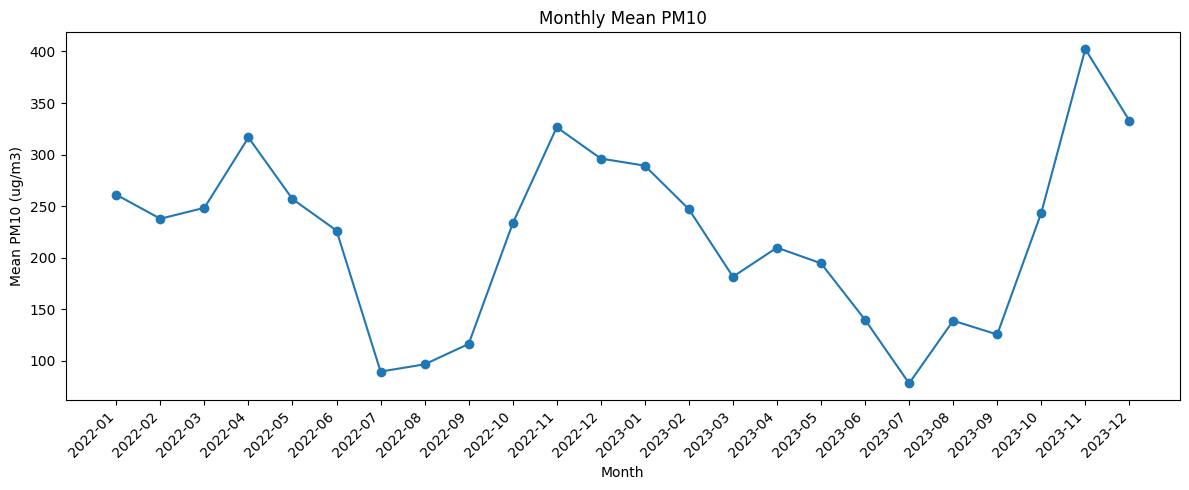

In [4]:
# Mean PM10 for each chronological month, in time order.
monthly_mean_pm10 = df.groupby('year_month')['pm10_ugm3'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_mean_pm10.index.astype(str), monthly_mean_pm10.values, marker='o')
plt.title('Monthly Mean PM10')
plt.xlabel('Month')
plt.ylabel('Mean PM10 (ug/m3)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What this does.** Repeats the same monthly grouping and line chart as above,
this time averaging PM10 instead of PM2.5.

**Why analysts use this analysis.** Plotting both pollutants the same way, on the
same monthly time axis, makes it possible to place the two charts side by side
and see whether they move in a similar pattern over time.

**How to interpret the output.** Read this line the same way as the PM2.5 line
above, and compare its shape against the PM2.5 chart -- do the peaks and dips
land in the same months, or not?

# Section 3 -- Monthly Weather

The same monthly-average, full-period line chart is now built for each of the
three weather variables: temperature, humidity, and wind speed.

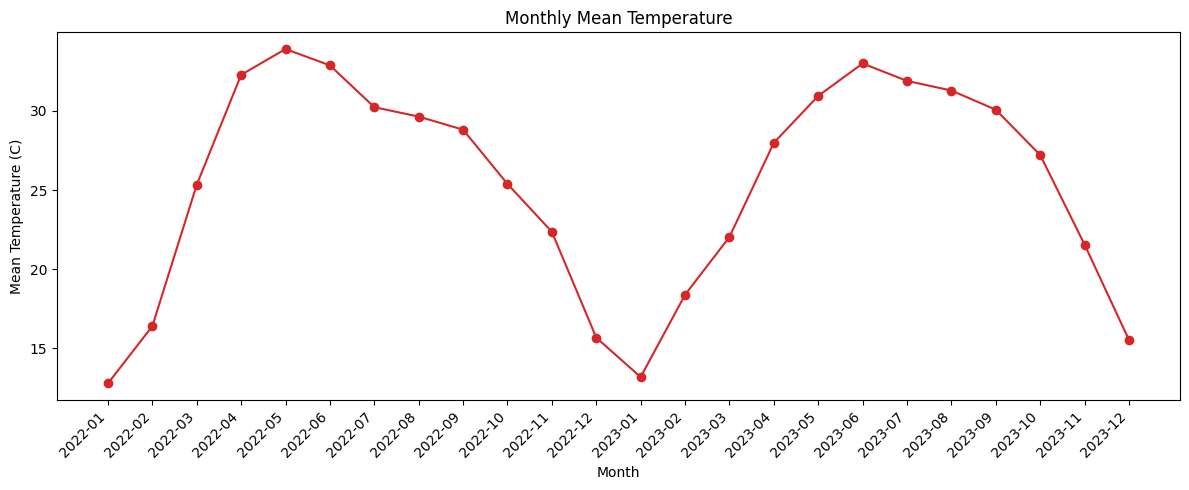

In [5]:
# Mean temperature for each chronological month, in time order.
monthly_mean_temp = df.groupby('year_month')['air_temp_c'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_mean_temp.index.astype(str), monthly_mean_temp.values, marker='o', color='tab:red')
plt.title('Monthly Mean Temperature')
plt.xlabel('Month')
plt.ylabel('Mean Temperature (C)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What this does.** Groups the dataset by chronological month, averages air
temperature within each month, and plots the monthly averages as a line in time
order.

**Why analysts use this analysis.** Weather variables are the natural backdrop
against which pollution moves. Viewing temperature on the same monthly time axis
as PM2.5 and PM10 makes any later, still-uninterpreted comparison between the two
kinds of series possible.

**How to interpret the output.** Read the line left to right as time passing, and
note whether it moves smoothly, in a wave-like seasonal shape, or in some other
pattern -- again without explaining why.

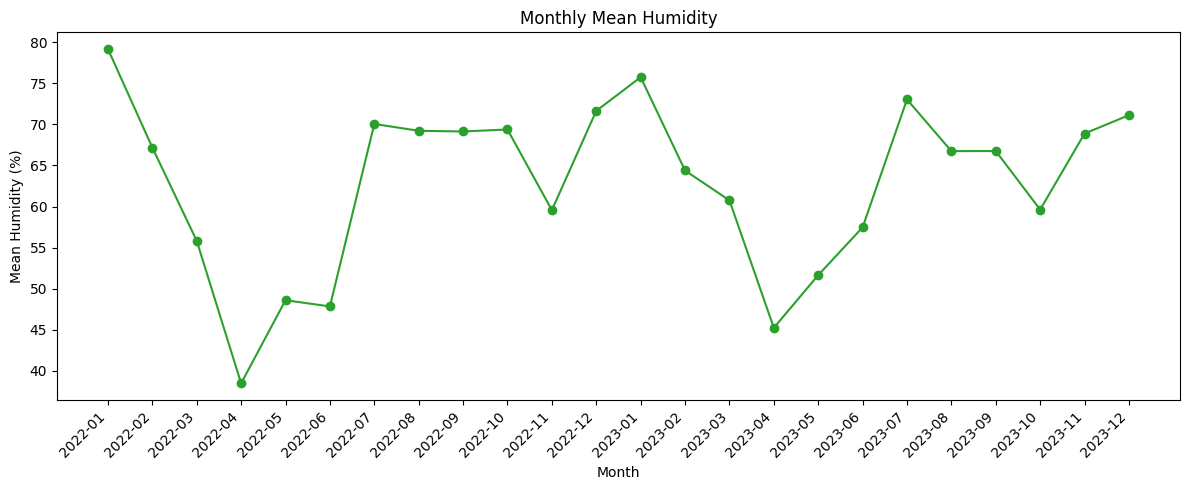

In [6]:
# Mean humidity for each chronological month, in time order.
monthly_mean_humidity = df.groupby('year_month')['rh_pct'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_mean_humidity.index.astype(str), monthly_mean_humidity.values, marker='o', color='tab:green')
plt.title('Monthly Mean Humidity')
plt.xlabel('Month')
plt.ylabel('Mean Humidity (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What this does.** Repeats the same monthly grouping and line chart construction,
this time averaging relative humidity within each chronological month.

**Why analysts use this analysis.** Humidity is bounded between 0% and 100% by
definition, so tracking its monthly average shows where within that fixed range
the data sits over time, on the same monthly axis as the other variables.

**How to interpret the output.** Read the line the same way as the temperature
line above. Note the overall range the line moves within, and whether it appears
to rise and fall on a repeating cycle.

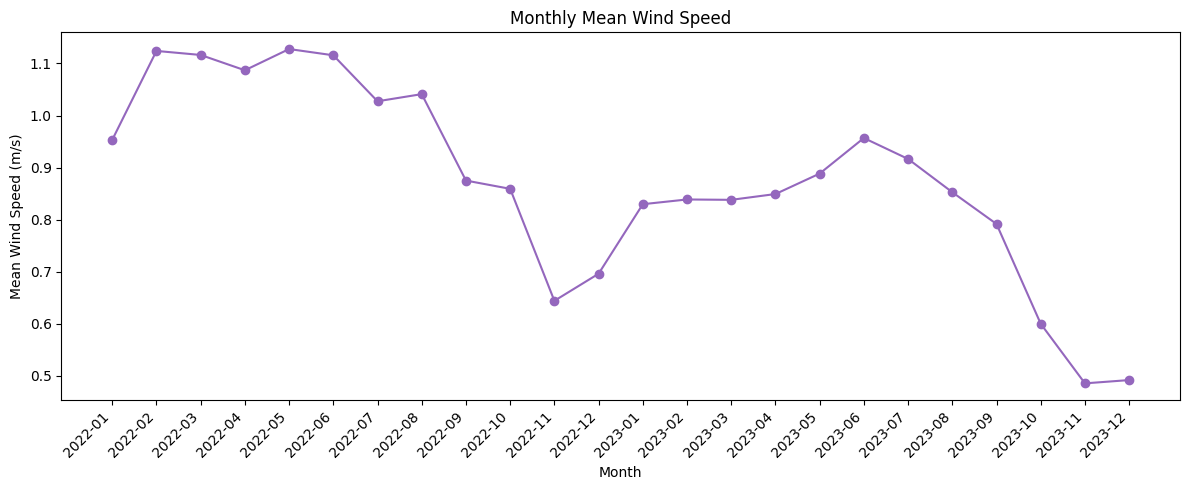

In [7]:
# Mean wind speed for each chronological month, in time order.
monthly_mean_wind_speed = df.groupby('year_month')['wind_speed_ms'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_mean_wind_speed.index.astype(str), monthly_mean_wind_speed.values, marker='o', color='tab:purple')
plt.title('Monthly Mean Wind Speed')
plt.xlabel('Month')
plt.ylabel('Mean Wind Speed (m/s)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What this does.** Repeats the same monthly grouping and line chart construction
a third time, averaging wind speed within each chronological month.

**Why analysts use this analysis.** Wind speed is the third weather variable that
can plausibly relate to how pollution disperses; charting it on the same monthly
basis keeps it directly comparable to the temperature and humidity charts above.

**How to interpret the output.** Read the line the same way as the other two
weather charts, and note whether its movement lines up in time with the rises and
falls seen in the temperature or humidity charts above.

# Section 4 -- Year Comparison

We now overlay the two calendar years on the same set of twelve months (January
through December) to see whether 2022 and 2023 follow a similar monthly pattern.
This section only builds the overlay charts; it does not interpret them.

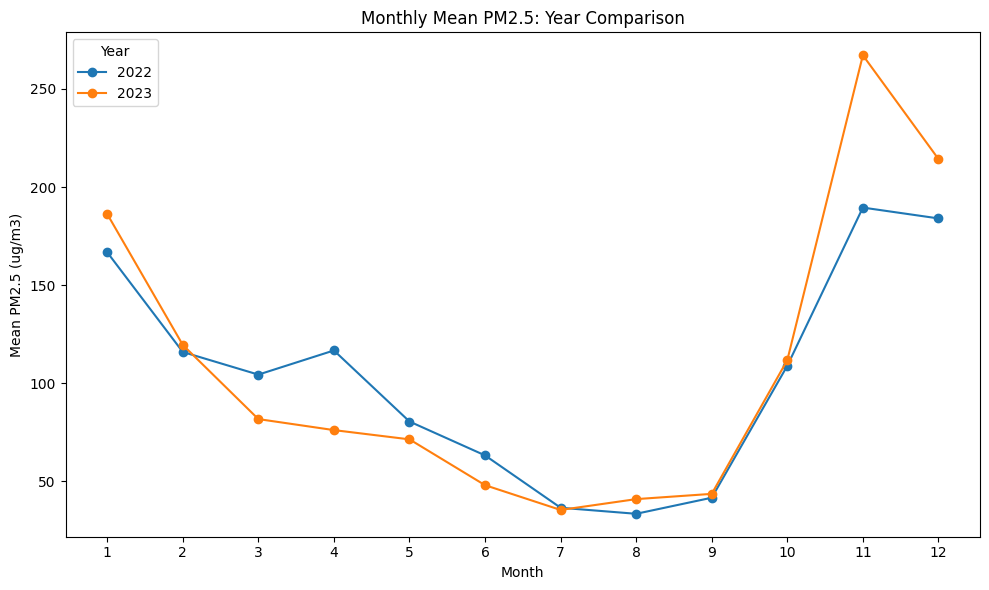

In [8]:
# Mean PM2.5 for each (year, calendar month) combination, then reshaped so
# each year becomes its own column with months 1-12 as the rows.
pm25_by_year_month = df.groupby(['year', 'month_number'])['pm25_ugm3'].mean()
pm25_year_comparison = pm25_by_year_month.unstack(level='year')

plt.figure(figsize=(10, 6))
for year_value in pm25_year_comparison.columns:
    plt.plot(
        pm25_year_comparison.index,
        pm25_year_comparison[year_value],
        marker='o',
        label=str(year_value),
    )
plt.title('Monthly Mean PM2.5: Year Comparison')
plt.xlabel('Month')
plt.ylabel('Mean PM2.5 (ug/m3)')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.tight_layout()
plt.show()

**What this does.** Groups the dataset by year and calendar month together,
averages PM2.5 within each combination, and reshapes the result so 2022 and 2023
each become a separate line plotted against the same twelve calendar months.

**Why analysts use this analysis.** Overlaying two years on the same month axis
is the standard way to line up two time periods for a side-by-side view, without
yet computing any difference or performing any statistical comparison between
them.

**How to interpret the output.** Compare the two lines month by month, noting
where they sit close together and where they diverge -- as a description of the
two lines' shapes only, not as an explanation of why they differ.

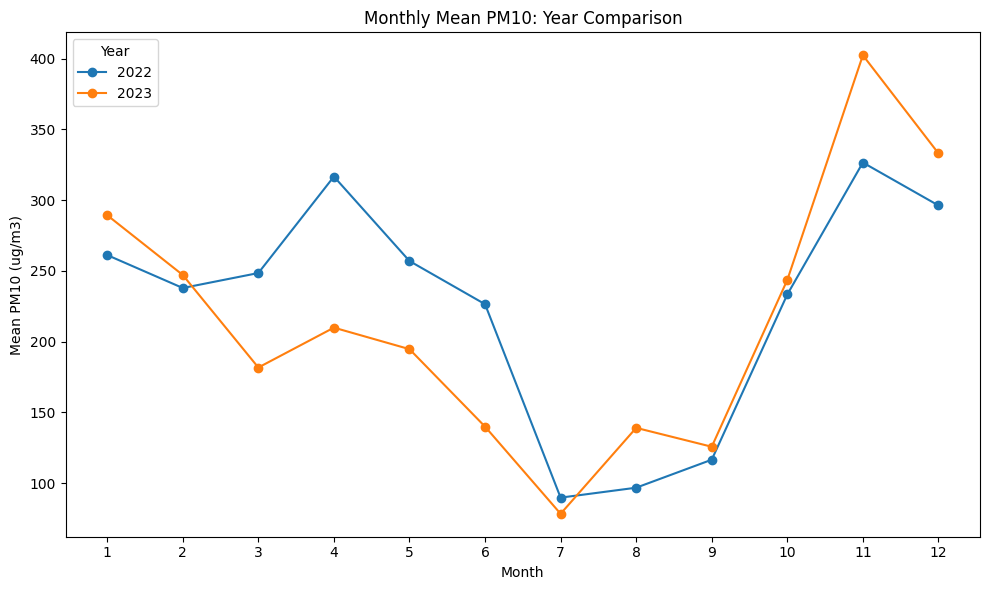

In [9]:
# Mean PM10 for each (year, calendar month) combination, reshaped the same way.
pm10_by_year_month = df.groupby(['year', 'month_number'])['pm10_ugm3'].mean()
pm10_year_comparison = pm10_by_year_month.unstack(level='year')

plt.figure(figsize=(10, 6))
for year_value in pm10_year_comparison.columns:
    plt.plot(
        pm10_year_comparison.index,
        pm10_year_comparison[year_value],
        marker='o',
        label=str(year_value),
    )
plt.title('Monthly Mean PM10: Year Comparison')
plt.xlabel('Month')
plt.ylabel('Mean PM10 (ug/m3)')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.tight_layout()
plt.show()

**What this does.** Repeats the same year-over-year overlay construction as
above, this time for PM10.

**Why analysts use this analysis.** Building the PM10 overlay the same way as the
PM2.5 overlay keeps the two charts directly comparable, and lets the same
calendar-month axis be reused for a second pollutant.

**How to interpret the output.** Compare the two years' lines the same way as the
PM2.5 overlay, and also compare this chart's shape against the PM2.5 overlay
above -- again, as description only.

# Section 5 -- Monthly Variability

Finally, we look at how much PM2.5 varies *within* each calendar month, not just
where its average sits, using one box plot per calendar month across both years
combined.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_34484\1394600649.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(pm25_by_month, labels=month_labels)


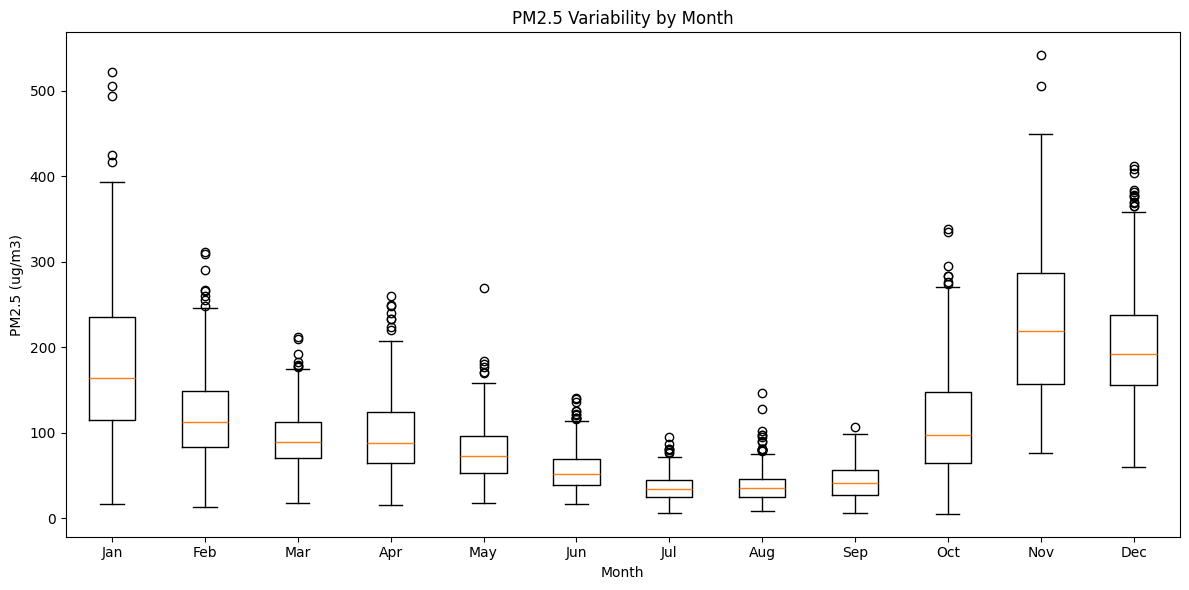

In [10]:
# Build one array of PM2.5 values per calendar month (1-12), pooling both years,
# dropping missing values since a box plot cannot use them.
month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec',
]
pm25_by_month = [
    df.loc[df['month_number'] == month, 'pm25_ugm3'].dropna()
    for month in range(1, 13)
]

plt.figure(figsize=(12, 6))
plt.boxplot(pm25_by_month, labels=month_labels)
plt.title('PM2.5 Variability by Month')
plt.xlabel('Month')
plt.ylabel('PM2.5 (ug/m3)')
plt.tight_layout()
plt.show()

**What this does.** Splits PM2.5 into twelve groups, one per calendar month
(pooling 2022 and 2023 together), and draws one box (median, quartiles, whiskers,
and outliers) per month on a single set of axes.

**Why analysts use this analysis.** A monthly mean, like the ones charted in
Section 2, reduces each month to a single number and hides how consistent or
erratic the days within that month actually were. Variability matters because two
months can share the same mean while one month's days cluster tightly around it
and the other month's days swing widely above and below it -- a difference the
mean alone cannot show. A box plot exposes that spread directly, month by month.

**How to interpret the output.** Compare box heights across months to see which
months show tightly clustered days versus widely spread ones, and note how many
outlier points appear above each box -- as description only, without explaining
why any month is more or less variable than another.

# Section 6 -- Questions Raised

Looking at pollution and weather over time above naturally raises the following
questions. They are recorded here as a to-do list for later sections -- **they
are not answered in this Time-Series Exploration notebook.**

1. Do the peaks in the monthly PM2.5 line correspond to the same months every
   year, or do they shift?
2. Why does PM2.5 or PM10 rise or fall in the months where the line changes most
   sharply?
3. Do temperature, humidity, and wind speed move in the same months as the
   pollution peaks and dips, or on a different schedule?
4. Are the months with the highest PM2.5 variability the same months with the
   highest PM2.5 mean, or are level and spread independent of each other here?
5. Where the 2022 and 2023 overlay lines diverge most, what is different about
   those specific months?
6. Is the monthly observation coverage checked in Section 1 related in any way to
   the months with the most variability in Section 5?
7. Do PM2.5 and PM10 track each other closely across all twelve months, or do they
   decouple in particular seasons?
8. Does the width of the box plot (the spread) change gradually across
   neighbouring months, or are there sudden jumps?
9. Are the outlier points in the monthly box plots concentrated in specific years,
   stations, or weeks?
10. How would this same set of monthly views look if it were built separately per
    station rather than for the city as a whole?

*End of the Time-Series Exploration notebook.*